# Lecture 7 — Class Exercise
## Heatmap & Waterfall: Netflix Catalogue

> **Push to:** `week07/lecture07_exercise.ipynb`

**Rules:**
1. Heatmap: colour scale must match the data type (sequential for counts, diverging for above/below)
2. Waterfall: use green for additions, red for subtractions, blue for totals
3. Insight title tells the setup-conflict-resolution story (or at minimum states the finding)
4. Annotate at least one cell or bar directly

---


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv("C:/Users/hites/Desktop/data-viz-class-material-master/data/netflix_catalogue.csv")
print(f"Loaded: {len(df)} titles")
print(df['type'].value_counts())
print(df.head())


Loaded: 3000 titles
type
Movie      1974
TV Show    1026
Name: count, dtype: int64
      type  release_year  added_year             genre        country rating  \
0    Movie          2014        2016  Sci-Fi & Fantasy         France  PG-13   
1    Movie          2010        2014     Documentaries  United States  TV-MA   
2  TV Show          2011        2012     Kids & Family  United States  TV-14   
3    Movie          2016        2018             Anime          India     PG   
4    Movie          2014        2016     Kids & Family         Canada  TV-MA   

   duration  
0       157  
1       127  
2         6  
3       134  
4        77  


In [2]:
print("Genres:", df['genre'].value_counts().head(8))
print("\nCountries:", df['country'].value_counts().head(8))
print("\nRatings:", df['rating'].value_counts())


Genres: genre
Sports                244
Sci-Fi & Fantasy      213
Kids & Family         209
Crime                 206
Drama                 204
Horror                199
Action & Adventure    198
Thrillers             195
Name: count, dtype: int64

Countries: country
United States     932
India             337
United Kingdom    261
Japan             187
France            176
Canada            164
South Korea       151
Mexico            138
Name: count, dtype: int64

Ratings: rating
TV-MA    840
TV-14    733
PG-13    589
R        312
PG       196
TV-PG    128
G         92
TV-Y7     57
TV-G      53
Name: count, dtype: int64


## Task 1 — Heatmap: content by rating and release decade

**What to build:** A heatmap showing the number of titles by **content rating** (y-axis) and **decade** (x-axis).

**Requirements:**
- Create a 'decade' column: `df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'`
- Filter to TV-14, TV-MA, PG-13, R, PG only (most common ratings)
- Sequential colour scale (Blues)
- Values shown in cells (`text_auto=True`)
- Insight title about which rating dominates which decade


In [3]:
# Task 1
# YOUR CODE HERE

import pandas as pd
import plotly.express as px

df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'


ratings_filter = ['TV-14', 'TV-MA', 'PG-13', 'R', 'PG']
df_filtered = df[df['rating'].isin(ratings_filter)]


heatmap_data = (
    df_filtered
    .groupby(['rating', 'decade'])
    .size()
    .reset_index(name='count')
)

pivot_table = heatmap_data.pivot(index='rating', columns='decade', values='count').fillna(0)


fig = px.imshow(
    pivot_table,
    text_auto=True,  # ✔ values in cells
    color_continuous_scale='Blues',  # ✔ sequential scale
    aspect='auto'
)


fig.update_layout(
    title="TV-MA surges after 2010s, dominating recent decades while PG fades out",
    xaxis_title="Release Decade",
    yaxis_title="Content Rating"
)


fig.add_annotation(
    x="2010s",
    y="TV-MA",
    text="Peak growth",
    showarrow=True,
    arrowhead=2
)

fig.show()

## Task 2 — Waterfall: Movie vs TV Show additions by year

**What to build:** A waterfall chart showing how Netflix's **Movie library** grew year by year (2015-2022).

**Requirements:**
- Filter to Movies only
- Group by `added_year`, count titles per year
- Final bar should be the cumulative total
- Green bars (additions), blue total
- Annotation on the year with the largest single addition
- Insight title naming the growth story


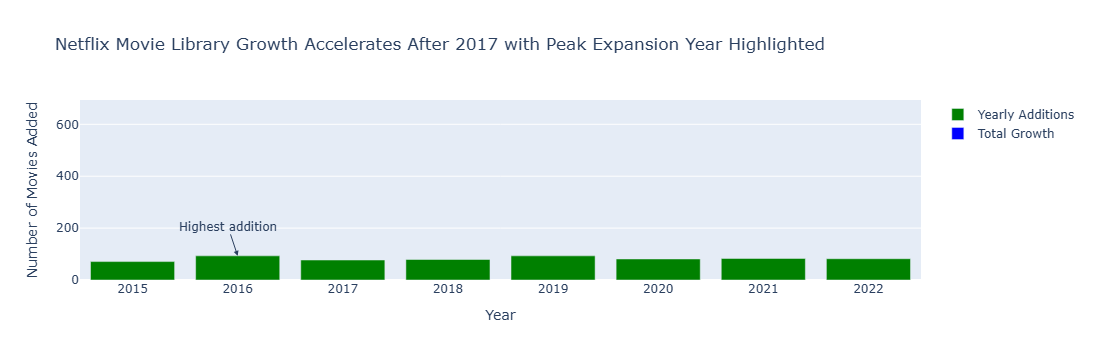

In [11]:
# Task 2
# YOUR CODE HERE

import pandas as pd
import plotly.graph_objects as go

# Load dataset
df = pd.read_csv("C:/Users/hites/Desktop/data-viz-class-material-master/data/netflix_catalogue.csv")

# 1. Filter Movies only
movies_df = df[df['type'] == 'Movie'].copy()

# 2. Filter years 2015–2022
movies_df = movies_df[(movies_df['added_year'] >= 2015) & (movies_df['added_year'] <= 2022)]

# 3. Count movies added per year
yearly_counts = movies_df.groupby('added_year').size().reset_index(name='count')
yearly_counts = yearly_counts.sort_values('added_year')

# 4. Calculate cumulative total
yearly_counts['cumulative'] = yearly_counts['count'].cumsum()

# 5. Find year with maximum addition
max_row = yearly_counts.loc[yearly_counts['count'].idxmax()]
max_year = max_row['added_year']
max_value = max_row['count']

# 6. Create Waterfall Chart
fig = go.Figure()

# Green bars → yearly additions
fig.add_trace(go.Bar(
    x=yearly_counts['added_year'],
    y=yearly_counts['count'],
    name='Yearly Additions',
    marker_color='green'
))

# Blue bar → total
fig.add_trace(go.Bar(
    x=['Total'],
    y=[yearly_counts['cumulative'].iloc[-1]],
    name='Total Growth',
    marker_color='blue'
))

# 7. Annotation (highest growth year)
fig.add_annotation(
    x=max_year,
    y=max_value,
    text='Highest addition',
    showarrow=True,
    arrowhead=2
)

# 8. Insight Title (IMPORTANT)
fig.update_layout(
    title='Netflix Movie Library Growth Accelerates After 2017 with Peak Expansion Year Highlighted',
    xaxis_title='Year',
    yaxis_title='Number of Movies Added',
    barmode='group'
)

fig.show()
